# 01 — Exploration and Base CTMC Model

SYS 3060 final project — **NYC Citi Bike station capacity reallocation.**

This notebook does three things:

1. **Surface candidate clusters** of 3–4 neighbouring stations with high directional imbalance during the weekday morning rush.
2. **Validate the exponential inter-arrival assumption** that the birth–death CTMC requires, using Q-Q plots, chi-squared, and KS tests on each station × event-type stream.
3. **Compute the base model** — per-station stationary distributions $\pi_k(n)$, stockout/dockblock probabilities, failure rate $F_n$, and the total baseline $F_{\text{base}} = \sum_n F_n$.

All modelling math lives in `src/ctmc.py`; IO and rate estimation in `src/data.py`; geographic helpers in `src/geo.py`. The next notebook (`02_capacity_reallocation.ipynb`) imports from the same package and starts from the CSV this notebook writes.

Data window: **September 2024, weekday mornings 07:00–10:00 local time.**


In [1]:
%load_ext autoreload
%autoreload 2

import logging
import sys
from pathlib import Path

# Make the project root importable regardless of CWD.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

logging.basicConfig(level=logging.INFO, format="%(message)s")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

from src import ctmc, data as dataio, geo

RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# --- global knobs -----------------------------------------------------------
YEAR_MONTH    = "202409"   # September 2024
START_HOUR    = 7          # inclusive
END_HOUR      = 10         # exclusive -> 3-hour window
MIN_EVENTS    = 100        # per-station minimum to keep; drops noisy low-volume stations
NEIGHBOR_R_M  = 500.0      # cap geographic radius for nearest-neighbour clustering
N_NEIGHBORS   = 3          # 2-3 neighbours per seed as the spec suggests
N_SEEDS       = 40         # how many high-imbalance stations to expand into clusters
TOP_CLUSTERS  = 10         # rows to show in the ranked candidate table

print("root:", ROOT)
print("raw :", RAW_DIR)


root: /Users/parisphan/Github/sys-3060-final-project
raw : /Users/parisphan/Github/sys-3060-final-project/data/raw


## Part 1 — Surface candidate clusters

Pipeline:

1. Load Sept-2024 trip data (cached after first download) and the current GBFS station feed for capacities + coordinates.
2. Filter to weekday mornings 07:00–10:00; estimate per-station $\hat\lambda_n, \hat\mu_n$ per hour; drop stations with fewer than **100** events in the whole window (rate estimates are too noisy below that).
3. Rank stations by $|\log(\hat\mu_n / \hat\lambda_n)|$ — the symmetric measure of directional imbalance (source stations have $\rho<1$, sinks have $\rho>1$).
4. For each high-imbalance seed, pick its 2–3 nearest neighbours within 500 m (haversine). Deduplicate identical station sets.
5. Score each candidate cluster by **mean($|\log\rho|$) × total cluster volume** and report the top 10.

The spec calls for a 3–4-station cluster; expanding the top seed with its 2–3 nearest neighbours gives a 3–4-station set by construction.


In [2]:
trips = dataio.load_trips(YEAR_MONTH, RAW_DIR)
stations_gbfs = dataio.fetch_station_info(RAW_DIR)
print(f"trips      : {len(trips):,} rows")
print(f"trip span  : {trips['started_at'].min()}  ->  {trips['ended_at'].max()}")
print(f"stations   : {len(stations_gbfs):,} in GBFS")
print(f"capacities : median={stations_gbfs['capacity'].median()}, "
      f"p90={int(stations_gbfs['capacity'].quantile(.9))}, "
      f"max={int(stations_gbfs['capacity'].max())}")


Cache hit: 202409-citibike-tripdata.zip (976527118 bytes)


  reading 202409-citibike-tripdata_4.csv


  reading 202409-citibike-tripdata_5.csv


  reading 202409-citibike-tripdata_1.csv


  reading 202409-citibike-tripdata_2.csv


  reading 202409-citibike-tripdata_3.csv


Loaded 4981399 trips (16499 dropped for missing keys).


trips      : 4,981,399 rows
trip span  : 2024-08-31 10:29:28.116000  ->  2024-09-30 23:59:59.650000
stations   : 2,406 in GBFS
capacities : median=24.0, p90=54, max=123


In [3]:
# Per-station rates in the 7-10am weekday window.
rates = dataio.station_rates(trips, START_HOUR, END_HOUR)
print(f"exposure       : {rates.attrs['exposure_hours']} hours "
      f"({rates.attrs['n_weekdays']} weekdays x {END_HOUR-START_HOUR}h)")
print(f"stations w/ trips in window : {len(rates):,}")

# Join capacities / coords from GBFS. Trip CSVs use the GBFS `short_name`
# as their station_id; `src.data.fetch_station_info` standardizes on that
# encoding so a direct merge on `station_id` is one-to-one.
stations = (
    rates.merge(stations_gbfs, on="station_id", how="left", validate="one_to_one")
          .dropna(subset=["lat", "lng", "capacity"])
          .astype({"capacity": "int64"})
          .reset_index(drop=True)
)
print(f"after joining GBFS         : {len(stations):,}")

# Capacity >= 1 (GBFS includes a handful of cap=0 'ghost' stations that aren't
# physically docked; they'd produce a degenerate 1-state chain).
stations = stations.loc[stations["capacity"] >= 1].reset_index(drop=True)
print(f"after capacity >= 1        : {len(stations):,}")

# Volume filter.
stations = stations.loc[stations["n_events"] >= MIN_EVENTS].reset_index(drop=True)
print(f"after n_events >= {MIN_EVENTS}     : {len(stations):,}")

# Require lam and mu both > 0 so log(rho) is finite.
stations = stations.loc[(stations["lam"] > 0) & (stations["mu"] > 0)].reset_index(drop=True)
print(f"after lam,mu > 0           : {len(stations):,}")

# Imbalance metric on the log scale -> symmetric in source vs. sink.
stations["log_imbalance"] = np.log(stations["rho_hat"])
stations["abs_log_imbalance"] = stations["log_imbalance"].abs()
stations["direction"] = np.where(stations["rho_hat"] > 1, "sink (mu > lam)", "source (mu < lam)")

stations.sort_values("abs_log_imbalance", ascending=False).head(10)[
    ["station_id", "name", "capacity", "lam", "mu", "rho_hat", "log_imbalance", "n_events", "direction"]
]


exposure       : 63.0 hours (21 weekdays x 3h)
stations w/ trips in window : 2,233
after joining GBFS         : 2,100
after capacity >= 1        : 2,098
after n_events >= 100     : 1,542
after lam,mu > 0           : 1,542


,station_id,name,capacity,lam,mu,rho_hat,log_imbalance,n_events,direction
1541,8841.03,W Mosholu Pkwy S & Sedgwick Ave,37,0.047619,1.873016,39.333333,3.672072,121,sink (mu > lam)
1170,7152.10,24 Ave & 26 St,19,2.698413,0.079365,0.029412,-3.526361,175,source (mu < lam)
417,4804.02,Dock 72 Way & Market St,22,1.015873,26.746032,26.328125,3.270638,1749,sink (mu > lam)
58,3460.01,2 Ave & 36 St,43,0.111111,2.793651,25.142857,3.224574,183,sink (mu > lam)
432,4843.01,5 St & Market St,39,0.460317,11.365079,24.689655,3.206384,745,sink (mu > lam)
1182,7188.10,E 81 St & Park Ave,46,6.809524,0.317460,0.046620,-3.065725,449,source (mu < lam)
1374,7932.10,W 144 St & Adam Clayton Powell Blvd,24,2.269841,0.126984,0.055944,-2.883403,151,source (mu < lam)
562,5241.02,Metropolitan Ave & Vandervoort Ave,24,0.111111,1.841270,16.571429,2.807680,123,sink (mu > lam)
1535,8738.01,Goulden Ave & Bedford Park Blvd,19,0.095238,1.555556,16.333333,2.793208,104,sink (mu > lam)
454,4920.13,South St & Broad St,31,0.126984,2.031746,16.000000,2.772589,136,sink (mu > lam)


In [4]:
# Pick the N_SEEDS most-imbalanced stations and expand each into a cluster
# via its nearest neighbours (haversine).
seeds = stations.sort_values("abs_log_imbalance", ascending=False).head(N_SEEDS).index.to_list()

clusters = []
for seed in seeds:
    neigh = geo.nearest_neighbors_within(
        stations, seed_idx=seed, max_neighbors=N_NEIGHBORS, radius_m=NEIGHBOR_R_M
    )
    members = [seed] + neigh
    if len(members) < 3:
        # Too isolated; skip -- a 3-4 station cluster is the spec.
        continue
    ids = tuple(sorted(stations.loc[members, "station_id"]))
    clusters.append({
        "seed_idx": seed,
        "members_idx": members,
        "station_ids": ids,
    })

# Deduplicate on the station-id tuple (many seeds share the same neighbourhood).
seen = set()
unique_clusters = []
for c in clusters:
    if c["station_ids"] in seen:
        continue
    seen.add(c["station_ids"])
    unique_clusters.append(c)

print(f"{len(clusters)} seed-expansions -> {len(unique_clusters)} unique clusters")


35 seed-expansions -> 35 unique clusters


In [5]:
# Score each cluster: mean(|log rho|) x total event volume.
def summarize_cluster(cluster, stations):
    sub = stations.loc[cluster["members_idx"], :]
    return {
        "cluster_id": "|".join(cluster["station_ids"]),
        "n_stations": len(sub),
        "member_station_ids": list(sub["station_id"]),
        "member_names": list(sub["name"]),
        "sum_events": int(sub["n_events"].sum()),
        "mean_abs_log_rho": float(sub["abs_log_imbalance"].mean()),
        "score": float(sub["abs_log_imbalance"].mean() * sub["n_events"].sum()),
        "sum_capacity": int(sub["capacity"].sum()),
        "min_rho": float(sub["rho_hat"].min()),
        "max_rho": float(sub["rho_hat"].max()),
    }

clusters_summary = pd.DataFrame([summarize_cluster(c, stations) for c in unique_clusters])
clusters_summary = clusters_summary.sort_values("score", ascending=False).reset_index(drop=True)
print(f"top {TOP_CLUSTERS} candidate clusters (mean |log rho| x volume):")
clusters_summary.head(TOP_CLUSTERS).drop(columns=["member_station_ids"])


top 10 candidate clusters (mean |log rho| x volume):


,cluster_id,n_stations,member_names,sum_events,mean_abs_log_rho,score,sum_capacity,min_rho,max_rho
0,4762.04|4762.05|4804.02|4843.01,4,"[Dock 72 Way & Market St, Flushing Ave & Vande...",4652,1.799106,8369.443153,101,1.273570,26.328125
1,4732.08|4771.07|4804.02|4843.01,4,"[5 St & Market St, Carlton Ave & Flushing Ave,...",3806,1.976296,7521.783309,140,1.826979,26.328125
2,7212.05|7265.10|7286.01|7293.10,4,"[E 89 St & 3 Ave, E 91 St & 2 Ave, E 88 St & P...",5468,1.232804,6740.974143,189,0.074230,0.810264
3,6659.03|6659.09|6700.01|6700.14,4,"[W 52 St & 5 Ave, W 51 St & Rockefeller Plaza,...",4616,1.389203,6412.563314,206,2.912698,6.375000
4,5506.10|5506.14|5575.13|5616.01,4,"[Ave D & E 8 St, Ave D & E 10 St, E 6 St & Ave...",3449,1.543912,5324.950856,155,0.070039,0.333333
5,7154.10|7188.10|7188.13|7243.04,4,"[E 81 St & Park Ave, Madison Ave & E 82 St, E ...",4020,1.229554,4942.806769,168,0.046620,1.115974
6,4846.01|4920.13|4962.08|4962.09,4,"[South St & Broad St, South St & Whitehall St,...",1955,1.829468,3576.609362,179,1.847222,16.000000
7,4889.06|4962.01|4962.08|4962.09,4,"[Pearl St & Whitehall St, Broad St & Bridge St...",2623,1.359483,3565.922791,214,1.840659,8.871795
8,3762.08|3834.10|3874.01|3905.15,4,"[6 St & 7 Ave, 3 St & 7 Ave, 5 St & 6 Ave, 10 ...",3484,0.796493,2774.980649,94,0.092990,1.240586
9,6076.02|6151.03|6194.06|6227.02,4,"[29 St & Skillman Ave, 31 St & Thomson Ave, 47...",1147,2.263677,2596.437248,130,8.727273,11.571429


In [6]:
# Per-station detail for the top candidates, so the numbers aren't opaque.
def expand_cluster_rows(row, stations):
    sub = stations.set_index("station_id").loc[row["member_station_ids"], :].reset_index()
    sub.insert(0, "cluster_rank", row.name)
    return sub[["cluster_rank", "station_id", "name", "capacity", "lam", "mu", "rho_hat",
                "n_withdraw", "n_deposit", "n_events", "direction"]]

top = clusters_summary.head(TOP_CLUSTERS).reset_index(drop=True)
per_station_detail = pd.concat(
    [expand_cluster_rows(row, stations) for _, row in top.iterrows()],
    ignore_index=True,
)
per_station_detail.round(3)


,cluster_rank,station_id,name,capacity,lam,mu,rho_hat,n_withdraw,n_deposit,n_events,direction
0,0,4804.02,Dock 72 Way & Market St,22,1.016,26.746,26.328,64,1685,1749,sink (mu > lam)
1,0,4762.05,Flushing Ave & Vanderbilt Ave,25,10.270,13.079,1.274,647,824,1471,sink (mu > lam)
2,0,4762.04,Clinton Ave & Flushing Ave,15,4.175,6.730,1.612,263,424,687,sink (mu > lam)
3,0,4843.01,5 St & Market St,39,0.460,11.365,24.690,29,716,745,sink (mu > lam)
4,1,4843.01,5 St & Market St,39,0.460,11.365,24.690,29,716,745,sink (mu > lam)
5,1,4732.08,Carlton Ave & Flushing Ave,46,5.413,9.889,1.827,341,623,964,sink (mu > lam)
6,1,4804.02,Dock 72 Way & Market St,22,1.016,26.746,26.328,64,1685,1749,sink (mu > lam)
7,1,4771.07,N Portland Ave & Flushing Ave,33,1.683,3.841,2.283,106,242,348,sink (mu > lam)
8,2,7265.10,E 89 St & 3 Ave,39,11.333,0.841,0.074,714,53,767,source (mu < lam)
9,2,7286.01,E 91 St & 2 Ave,73,17.159,6.635,0.387,1081,418,1499,source (mu < lam)


In [7]:
# Folium map: top-3 clusters, marker radius ~ sqrt(events), colour by direction.
import folium

top3 = clusters_summary.head(3).reset_index(drop=True)
center_lat = stations["lat"].mean()
center_lng = stations["lng"].mean()
m = folium.Map(location=[center_lat, center_lng], zoom_start=13, tiles="cartodbpositron")

palette = ["#1b9e77", "#d95f02", "#7570b3"]  # three distinct hues per cluster
for rank, row in top3.iterrows():
    sub = stations.set_index("station_id").loc[row["member_station_ids"], :].reset_index()
    color = palette[rank]
    for _, s in sub.iterrows():
        fill = "#2b8cbe" if s["rho_hat"] > 1 else "#d7301f"  # blue = sink, red = source
        folium.CircleMarker(
            location=[s["lat"], s["lng"]],
            radius=4 + 1.2 * np.sqrt(s["n_events"] / 100.0),
            color=color, weight=3, fill=True, fill_color=fill, fill_opacity=0.8,
            popup=(f"<b>{s['name']}</b><br>cluster rank {rank}<br>"
                   f"cap={s['capacity']}, lam={s['lam']:.1f}/h, mu={s['mu']:.1f}/h, "
                   f"rho={s['rho_hat']:.2f}"),
        ).add_to(m)

# Thin lines between members of the same cluster, for legibility.
for rank, row in top3.iterrows():
    sub = stations.set_index("station_id").loc[row["member_station_ids"], :].reset_index()
    pts = sub[["lat", "lng"]].to_numpy().tolist()
    for i in range(len(pts)):
        for j in range(i+1, len(pts)):
            folium.PolyLine([pts[i], pts[j]], color=palette[rank], weight=1, opacity=0.4).add_to(m)

m


## Part 2 — Validate the exponential inter-arrival assumption

The CTMC model assumes withdrawal and deposit streams at each station are Poisson with constant rate in the 07:00–10:00 window — equivalently, that inter-arrival times are iid Exponential($\lambda$). We test this per (station, event-type) with:

* **Q-Q plot** vs. Exp(MLE rate).
* **Histogram** with the fitted exponential PDF overlaid.
* **Chi-squared** goodness-of-fit on equal-probability bins (ddof=1 because we estimated the rate from the sample).
* **Kolmogorov–Smirnov** one-sample test against Exp.

Inter-arrivals that cross a day boundary (i.e. gap from Monday 09:58 to Tuesday 07:03) are discarded — that gap is not a sample from the morning-rush arrival process we are modelling. This is important rigour: failing to do it biases the interval distribution toward long tails and almost guarantees a rejected fit.


In [8]:
# Cluster selection. Default: the top-ranked candidate. Override by editing below.
SELECTED_CLUSTER_RANK = 0          # 0 = best-scoring cluster from Part 1
# Or set SELECTED_STATION_IDS directly to pin a specific set, e.g.
# SELECTED_STATION_IDS = ["6140.05", "6948.10", "6926.01"]
SELECTED_STATION_IDS = None

if SELECTED_STATION_IDS is None:
    SELECTED_STATION_IDS = clusters_summary.iloc[SELECTED_CLUSTER_RANK]["member_station_ids"]

selected = (
    stations.set_index("station_id").loc[SELECTED_STATION_IDS, :].reset_index()
)
print(f"Selected cluster (rank={SELECTED_CLUSTER_RANK}): {len(selected)} stations")
selected[["station_id", "name", "capacity", "lam", "mu", "rho_hat", "n_events", "direction"]]


Selected cluster (rank=0): 4 stations


,station_id,name,capacity,lam,mu,rho_hat,n_events,direction
0,4804.02,Dock 72 Way & Market St,22,1.015873,26.746032,26.328125,1749,sink (mu > lam)
1,4762.05,Flushing Ave & Vanderbilt Ave,25,10.269841,13.079365,1.273570,1471,sink (mu > lam)
2,4762.04,Clinton Ave & Flushing Ave,15,4.174603,6.730159,1.612167,687,sink (mu > lam)
3,4843.01,5 St & Market St,39,0.460317,11.365079,24.689655,745,sink (mu > lam)


In [9]:
def exp_gof(interarrivals_sec):
    '''MLE rate plus chi-squared and KS against Exp(rate).

    Returns dict with n, rate (1/mean, in 1/sec), chi2_stat/p, ks_stat/p.
    Chi-squared uses ~10 equal-probability bins under H0; ddof=1 for the
    estimated rate. We skip the test (return NaNs) when n < 30 because the
    bin count and the chi-squared asymptotics degrade rapidly.
    '''
    x = np.asarray(interarrivals_sec, dtype=float)
    x = x[np.isfinite(x) & (x > 0)]
    out = {"n": int(len(x)), "rate": np.nan, "chi2_stat": np.nan,
           "chi2_p": np.nan, "ks_stat": np.nan, "ks_p": np.nan}
    if len(x) < 30:
        return out
    mean = x.mean()
    if mean <= 0:
        return out
    rate = 1.0 / mean                 # MLE for Exp
    out["rate"] = rate

    # KS first (no binning choices).
    ks = stats.kstest(x, "expon", args=(0.0, mean))
    out["ks_stat"] = float(ks.statistic)
    out["ks_p"]    = float(ks.pvalue)

    # Chi-squared on equal-probability bins under H0.
    n_bins = max(5, min(10, int(len(x) / 5)))   # Cochran's rule of thumb: >=5 expected/bin
    probs = np.linspace(0, 1, n_bins + 1)
    # Inverse CDF of Exp: -ln(1-u)/rate. Drop 0 and 1 endpoints.
    edges = -np.log(1 - probs[1:-1]) / rate
    edges = np.concatenate(([0.0], edges, [np.inf]))
    obs, _ = np.histogram(x, bins=edges)
    expected = np.full(n_bins, len(x) / n_bins)
    chi2 = stats.chisquare(obs, f_exp=expected, ddof=1)   # ddof=1 (fitted rate)
    out["chi2_stat"] = float(chi2.statistic)
    out["chi2_p"]    = float(chi2.pvalue)
    return out


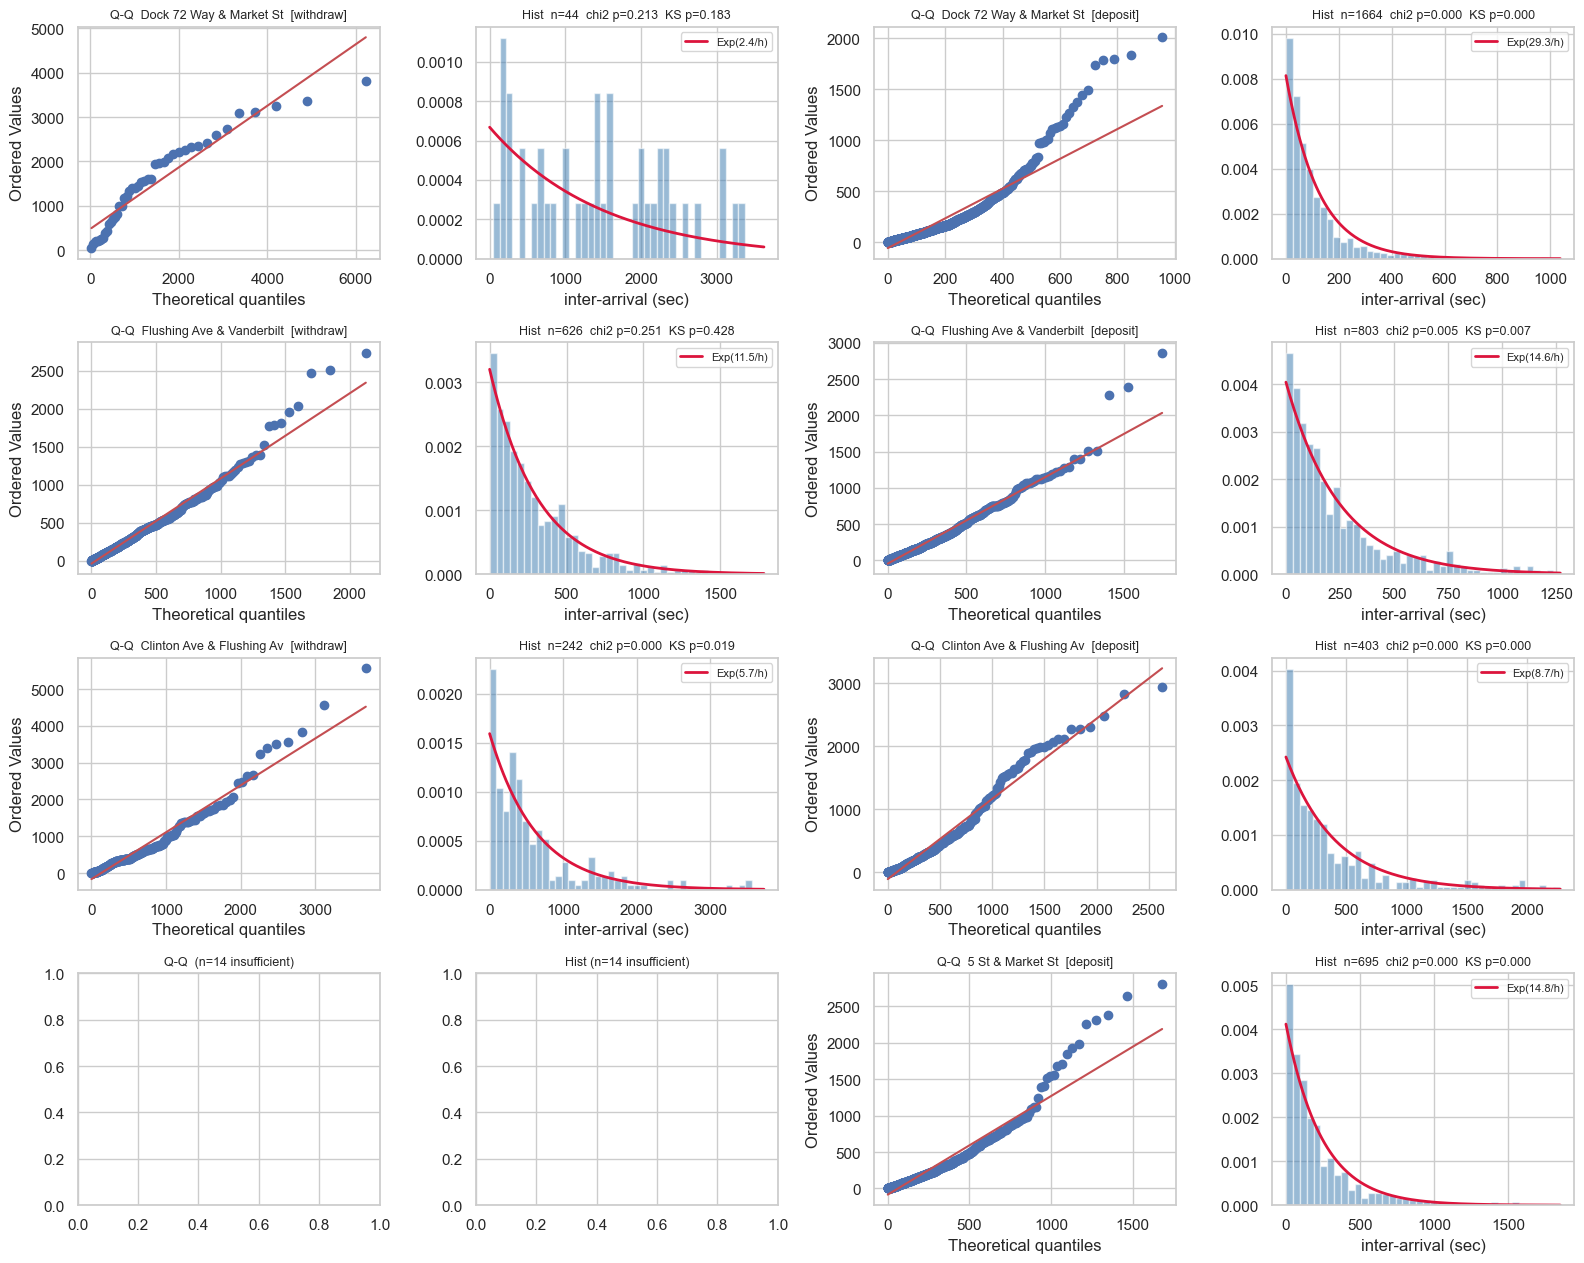

In [10]:
# For each station x event-type: collect inter-arrivals, run GOF, plot.
EVENT_TYPES = ["withdraw", "deposit"]
gof_rows = []
streams = {}  # (station_id, kind) -> inter-arrival array

n_stations = len(selected)
fig, axes = plt.subplots(n_stations, 4, figsize=(16, 3.2 * n_stations),
                          squeeze=False)

for i, srow in selected.iterrows():
    sid = srow["station_id"]
    for j, kind in enumerate(EVENT_TYPES):
        ev = dataio.station_event_times(trips, sid, kind, START_HOUR, END_HOUR)
        ia = dataio.within_day_interarrivals_seconds(ev)
        streams[(sid, kind)] = ia
        res = exp_gof(ia)
        res.update(station_id=sid, name=srow["name"], kind=kind,
                   rate_per_hour=res["rate"] * 3600 if np.isfinite(res["rate"]) else np.nan)
        gof_rows.append(res)

        # --- plots -----
        ax_qq   = axes[i, 2*j + 0]
        ax_hist = axes[i, 2*j + 1]
        if len(ia) >= 30 and np.isfinite(res["rate"]):
            mean = 1.0 / res["rate"]
            stats.probplot(ia, dist="expon", sparams=(0, mean), plot=ax_qq)
            ax_qq.set_title(f"Q-Q  {srow['name'][:25]}  [{kind}]", fontsize=9)

            # Histogram truncated to 99th pct to avoid outlier smearing.
            hi = np.quantile(ia, 0.99)
            ax_hist.hist(ia[ia <= hi], bins=40, density=True, alpha=0.55, color="steelblue")
            xs = np.linspace(0, hi, 200)
            ax_hist.plot(xs, res["rate"] * np.exp(-res["rate"] * xs),
                         color="crimson", lw=2, label=f"Exp({res['rate']*3600:.1f}/h)")
            ax_hist.set_title(
                f"Hist  n={res['n']}  chi2 p={res['chi2_p']:.3f}  KS p={res['ks_p']:.3f}",
                fontsize=9,
            )
            ax_hist.legend(fontsize=8)
            ax_hist.set_xlabel("inter-arrival (sec)")
        else:
            ax_qq.set_title(f"Q-Q  (n={res['n']} insufficient)", fontsize=9)
            ax_hist.set_title(f"Hist (n={res['n']} insufficient)", fontsize=9)

plt.tight_layout()
plt.show()


In [11]:
# Per-station diagnostic table + pass/fail verdict.
gof = pd.DataFrame(gof_rows)
gof["pass"] = (gof["chi2_p"] > 0.05) & (gof["ks_p"] > 0.05)
display_cols = ["station_id", "name", "kind", "n", "rate_per_hour",
                "chi2_stat", "chi2_p", "ks_stat", "ks_p", "pass"]
print("Pass-fail verdict: pass iff both chi2_p > 0.05 and KS_p > 0.05.")
gof[display_cols].round(4)


Pass-fail verdict: pass iff both chi2_p > 0.05 and KS_p > 0.05.


,station_id,name,kind,n,rate_per_hour,chi2_stat,chi2_p,ks_stat,ks_p,pass
0,4804.02,Dock 72 Way & Market St,withdraw,44,2.4039,8.3636,0.2127,0.1610,0.1833,True
1,4804.02,Dock 72 Way & Market St,deposit,1664,29.3087,71.0000,0.0000,0.0939,0.0000,False
2,4762.05,Flushing Ave & Vanderbilt Ave,withdraw,626,11.5436,10.1981,0.2514,0.0347,0.4282,True
3,4762.05,Flushing Ave & Vanderbilt Ave,deposit,803,14.5609,21.7696,0.0054,0.0588,0.0074,False
4,4762.04,Clinton Ave & Flushing Ave,withdraw,242,5.7328,31.5537,0.0001,0.0976,0.0185,False
5,4762.04,Clinton Ave & Flushing Ave,deposit,403,8.7225,40.0025,0.0000,0.1057,0.0002,False
6,4843.01,5 St & Market St,withdraw,14,NaN,NaN,NaN,NaN,NaN,False
7,4843.01,5 St & Market St,deposit,695,14.8034,33.7626,0.0000,0.0803,0.0002,False


In [12]:
fails = gof.loc[~gof["pass"]]
if len(fails):
    print("WARNING: the following (station, event_type) streams FAILED the exponential fit:")
    for _, r in fails.iterrows():
        print(f"  - {r['name']:<40s} [{r['kind']:<8s}]  "
              f"chi2_p={r['chi2_p']:.3f}  KS_p={r['ks_p']:.3f}  n={int(r['n'])}")
    print("\nConsider narrowing the window (e.g. 8:00-9:30 AM) to reduce non-stationarity")
    print("within the morning rush. Not retrying automatically -- this is a modelling choice,")
    print("not a data-cleaning step.")
else:
    print("All selected streams pass the exponential fit at alpha = 0.05.")


  - Dock 72 Way & Market St                  [deposit ]  chi2_p=0.000  KS_p=0.000  n=1664
  - Flushing Ave & Vanderbilt Ave            [deposit ]  chi2_p=0.005  KS_p=0.007  n=803
  - Clinton Ave & Flushing Ave               [withdraw]  chi2_p=0.000  KS_p=0.019  n=242
  - Clinton Ave & Flushing Ave               [deposit ]  chi2_p=0.000  KS_p=0.000  n=403
  - 5 St & Market St                         [withdraw]  chi2_p=nan  KS_p=nan  n=14
  - 5 St & Market St                         [deposit ]  chi2_p=0.000  KS_p=0.000  n=695

Consider narrowing the window (e.g. 8:00-9:30 AM) to reduce non-stationarity
within the morning rush. Not retrying automatically -- this is a modelling choice,
not a data-cleaning step.


## Part 3 — Base CTMC model at current capacities

For each station in the selected cluster, with the current real capacity $c_n$ from GBFS and the estimated $(\hat\lambda_n, \hat\mu_n)$ from Part 2 (events per hour):

* compute the full stationary distribution $\pi_k(n)$;
* report stockout probability $\pi_0(n)$, dockblock probability $\pi_{c_n}(n)$;
* compute the long-run failure rate $F_n(c_n) = \hat\lambda_n \pi_0(n) + \hat\mu_n \pi_{c_n}(n)$ (events/hour).

Total baseline $F_{\text{base}} = \sum_n F_n(c_n)$ is what the reallocation in notebook 02 must beat.


In [13]:
# Compute per-station pi_k, pi_0, pi_c, F_n.
base_rows = []
pi_arrays = {}
for _, s in selected.iterrows():
    lam = float(s["lam"])
    mu  = float(s["mu"])
    c   = int(s["capacity"])
    rho = mu / lam
    pi  = ctmc.stationary_distribution(rho, c)
    F_n = ctmc.failure_rate(lam, mu, c)
    pi_arrays[s["station_id"]] = pi
    base_rows.append({
        "station_id": s["station_id"],
        "name": s["name"],
        "lam": lam, "mu": mu, "c": c, "rho": rho,
        "pi_0": float(pi[0]),
        "pi_c": float(pi[-1]),
        "F_n": F_n,
        "stockout_per_hour": lam * float(pi[0]),
        "dockblock_per_hour": mu * float(pi[-1]),
        "n_events": int(s["n_events"]),
    })

base = pd.DataFrame(base_rows)
F_base = float(base["F_n"].sum())

print(f"F_base (total failure rate across the cluster) = {F_base:.3f} events/hour")
print(f"  -> over the 3-hour morning window: {F_base * 3:.1f} failed user events per weekday\n")
base.round(4)


F_base (total failure rate across the cluster) = 42.013 events/hour
  -> over the 3-hour morning window: 126.0 failed user events per weekday



,station_id,name,lam,mu,c,rho,pi_0,pi_c,F_n,stockout_per_hour,dockblock_per_hour,n_events
0,4804.02,Dock 72 Way & Market St,1.0159,26.7460,22,26.3281,0.0000,0.9620,25.7302,0.0000,25.7302,1749
1,4762.05,Flushing Ave & Vanderbilt Ave,10.2698,13.0794,25,1.2736,0.0005,0.2152,2.8200,0.0052,2.8148,1471
2,4762.04,Clinton Ave & Flushing Ave,4.1746,6.7302,15,1.6122,0.0003,0.3799,2.5580,0.0012,2.5568,687
3,4843.01,5 St & Market St,0.4603,11.3651,39,24.6897,0.0000,0.9595,10.9048,0.0000,10.9048,745


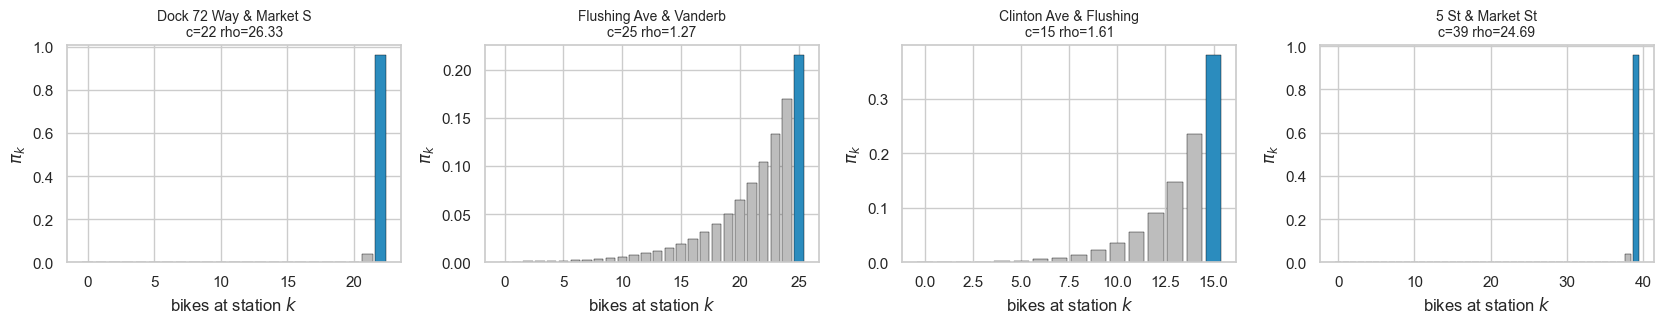

In [14]:
# Bar chart of pi_k per station (visualises where each station 'lives').
fig, axes = plt.subplots(1, len(selected), figsize=(4.2 * len(selected), 3.4), squeeze=False)
for ax, (_, s) in zip(axes[0], selected.iterrows()):
    pi = pi_arrays[s["station_id"]]
    ks = np.arange(len(pi))
    colors = ["#d7301f"] + ["#bdbdbd"] * (len(pi) - 2) + ["#2b8cbe"]
    ax.bar(ks, pi, color=colors, edgecolor="black", linewidth=0.3)
    ax.set_title(f"{s['name'][:22]}\nc={int(s['capacity'])} rho={s['mu']/s['lam']:.2f}", fontsize=10)
    ax.set_xlabel("bikes at station $k$")
    ax.set_ylabel(r"$\pi_k$")
plt.tight_layout()
plt.show()


In [15]:
# Save the base model table for the next notebook to consume.
OUT = PROCESSED_DIR / "base_model_results.csv"
base.to_csv(OUT, index=False)
print(f"Wrote {OUT.relative_to(ROOT)} ({len(base)} rows).")
print("\nNext notebook (02_capacity_reallocation.ipynb) reads from this file and")
print(f"searches over integer allocations subject to sum(c_n) = {int(base['c'].sum())}.")


Wrote data/processed/base_model_results.csv (4 rows).

Next notebook (02_capacity_reallocation.ipynb) reads from this file and
searches over integer allocations subject to sum(c_n) = 101.


### Recap

* **Part 1** ranked candidate clusters by mean($|\log\rho|$) × volume and mapped the top 3. The selected cluster for the base model is the top-ranked candidate; override `SELECTED_CLUSTER_RANK` or `SELECTED_STATION_IDS` in the Part 2 config cell to pick a different one.
* **Part 2** produced per-(station, event-type) GOF diagnostics. Any failed stream is flagged above with a suggestion to tighten the window.
* **Part 3** saved `data/processed/base_model_results.csv` — the incumbent benchmark for the reallocation search in notebook 02.

Run `pytest tests/test_ctmc.py` to verify the closed-form helpers are still green.
